In [2]:
import numpy as np
import tensorflow as tf
import sys
import os

sys.path.insert(1, './seld-net')
import cls_data_generator
import parameter
import evaluation_metrics

import matplotlib.pyplot as plt
%matplotlib inline


2025-07-09 13:08:04.763625: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752041284.783270  429141 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752041284.803527  429141 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752041284.875830  429141 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752041284.875855  429141 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752041284.875857  429141 computation_placer.cc:177] computation placer alr

In [3]:
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print(tf.config.experimental.list_physical_devices('GPU'))


Num GPUs Available:  1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
model = tf.keras.models.load_model('./models/criset_0.120m_3class_motor_ov1_split1_regr0_3d0_55_criset_0.120m_whistle_drone_50LossWeights,_model.keras')

model.summary()

I0000 00:00:1752041290.788122  429141 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2266 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 16, 512,   │          0 │ -                 │
│ (InputLayer)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 512,   │      9,280 │ input_layer[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 512,   │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 512,   │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 512,   │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 512,   │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 512,   │     36,928 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 512,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 512,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 512,   │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 512,   │          0 │ max_pooling2d_1[… │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 512,   │     36,928 │ dropout_1[0][0]   │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 512,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 512,   │          0 │ batch_normalizat… │
│ (Activation)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 512,   │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 512,   │          0 │ max_pooling2d_2[… │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 512, 64,   │          0 │ dropout_2[0][0] 

 Total params: 1,542,365 (5.88 MB)

 Trainable params: 513,993 (1.96 MB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 1,027,988 (3.92 MB)

In [15]:
params = parameter.get_params("20")
batch_size = 16

data_gen_test = cls_data_generator.DataGenerator(
        dataset=params['dataset'], ov=params['overlap'], split=params['split'], db=params['db'], nfft=params['nfft'],
        batch_size=batch_size, seq_len=params['sequence_length'], classifier_mode=params['mode'],
        weakness=params['weakness'], datagen_mode='train', cnn3d=params['cnn_3d'], xyz_def_zero=params['xyz_def_zero'],
        azi_only=params['azi_only'], shuffle=False
    )

azimuth_only = params['azi_only']
temp_sed_batch = next(data_gen_test.generate())[1][0]
num_of_class = int(temp_sed_batch.shape[2])

SET: 20
quick_test: False
azi_only: True
dataset: criset_0.120m_3class_motor
overlap: 1
split: 1
db: 30
nfft: 512
sequence_length: 512
batch_size: 2
dropout_rate: 0.0
nb_cnn2d_filt: 64
pool_size: [8, 8, 2]
rnn_size: [128, 128]
fnn_size: [128]
loss_weights: [1.0, 50.0]
xyz_def_zero: True
nb_epochs: 1000
mode: regr
nb_cnn3d_filt: 32
cnn_3d: False
weakness: 0
patience: 100


FileNotFoundError: [Errno 2] No such file or directory: './dataset_generator/sounds/criset_0.120m_3class_motor/spec_ov1_split1_30db_nfft512_norm/train_89_desc_30_100.wav.npy'

In [6]:
print(data_gen_test.get_data_sizes())
print("feature shape: ", next(data_gen_test.generate())[0].shape)
print("SED shape: ", next(data_gen_test.generate())[1][0].shape)
print("DOA shape: ", next(data_gen_test.generate())[1][1].shape)

((16, 16, 512, 256), [(16, 512, 11), (16, 512, 22)])
feature shape:  (16, 16, 512, 256)
SED shape:  (16, 512, 11)
DOA shape:  (16, 512, 22)


In [7]:
pred = model.predict_on_batch(
    next(data_gen_test.generate())[0][:, :, :, :],
)
print("SED shape: ", pred[0].shape)
print("DOA shape: ", pred[1].shape)

2025-07-09 13:08:27.649542: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 268435456 exceeds 10% of free system memory.
I0000 00:00:1752041311.995653  433408 cuda_dnn.cc:529] Loaded cuDNN version 90501


SED shape:  (16, 512, 3)
DOA shape:  (16, 512, 6)


IndexError: index 3 is out of bounds for axis 1 with size 3

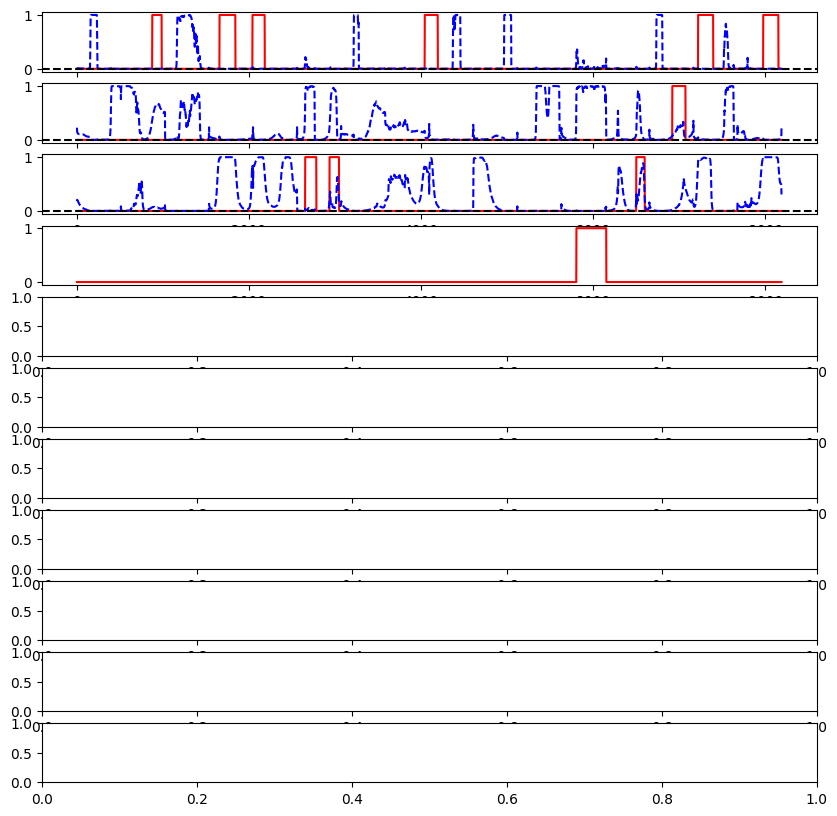

In [9]:
labels = next(data_gen_test.generate())[1][0][:, :, :].squeeze()
labels = np.concatenate([labels[n, :] for n in range(labels.shape[0])])
if len(labels.shape) == 1:
    labels = np.atleast_2d(labels).T
    
predictions = np.concatenate(([pred[0][n, :, :] for n in range(pred[0].shape[0])]))

%matplotlib inline

fig, ax = plt.subplots(num_of_class, figsize=(10, 10))
ax = np.atleast_1d(ax)
for i in range(num_of_class):
    ax[i].plot(labels[:, i], label='Difference', color='red')
    ax[i].plot(predictions[:, i], label='Difference', color='blue', linestyle='--')
    ax[i].axhline(y=0, color='black', linestyle='--')

# fig.legend()
plt.tight_layout()
plt.show()

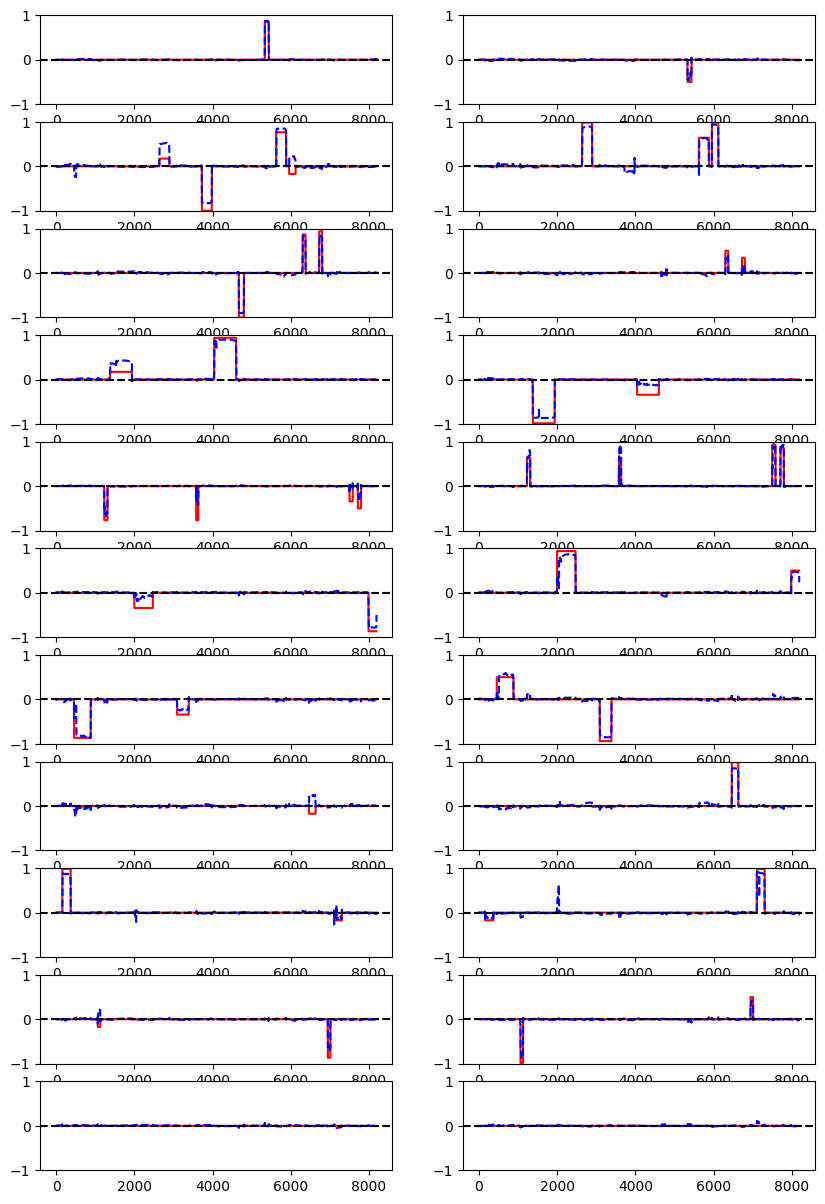

In [22]:
doa_labels = next(data_gen_test.generate())[1][1][:, :, :]

x_labels = np.concatenate([doa_labels[n, :, :] for n in range(doa_labels.shape[0])])
y_labels = np.concatenate([doa_labels[n, :, :] for n in range(doa_labels.shape[0])])
z_labels = np.concatenate([doa_labels[n, :, :] for n in range(doa_labels.shape[0])])

x_pred = np.concatenate(([pred[1][n, :, :] for n in range(pred[0].shape[0])]))
y_pred = np.concatenate(([pred[1][n, :, :] for n in range(pred[0].shape[0])]))
z_pred = np.concatenate(([pred[1][n, :, :] for n in range(pred[0].shape[0])]))

%matplotlib inline
fig, ax = plt.subplots(num_of_class, 2 if azimuth_only else 3, figsize=(10, 15))
ax = np.atleast_2d(ax)

for i in range(num_of_class):
    ax[i][0].plot(x_labels[:, i], label='Actual', color='red')
    ax[i][0].plot(x_pred[:, i], label='Predicted', color='blue', linestyle='--')
    ax[i][0].axhline(y=0, color='black', linestyle='--')
    ax[i][0].set_ylim([-1, 1])

    ax[i][1].plot(x_labels[:, i + num_of_class], label='Actual', color='red')
    ax[i][1].plot(x_pred[:, i + num_of_class], label='Predicted', color='blue', linestyle='--')
    ax[i][1].axhline(y=0, color='black', linestyle='--')
    ax[i][1].set_ylim([-1, 1])

# fig.legend()
# plt.tight_layout()
plt.show()

In [154]:
sed_pred = evaluation_metrics.reshape_3Dto2D(pred[0]) > 0.5
doa_pred = evaluation_metrics.reshape_3Dto2D(pred[1])

In [ ]:
sed_gt = np.zeros_like(sed_pred)
doa_gt = np.zeros_like(doa_pred)

i = 1
for feat, label in data_gen_test.generate():
    sed_gt[(i-1) * params['sequence_length'] * params['batch_size'] : i * params['sequence_length'] * params['batch_size'], : ] = evaluation_metrics.reshape_3Dto2D(label[0])
    doa_gt[(i-1) * params['sequence_length'] * params['batch_size'] : i * params['sequence_length'] * params['batch_size'], : ] = evaluation_metrics.reshape_3Dto2D(label[1])
    i += 1
    if i == data_gen_test.get_total_batches_in_data():
        break

In [ ]:
doa_loss, conf_mat = evaluation_metrics.compute_doa_scores_regr_xyz(doa_pred, doa_gt, sed_pred, sed_gt)
sed_loss = evaluation_metrics.compute_sed_scores(sed_pred, sed_gt, data_gen_test.nb_frames_1s())

In [46]:
import pyaudio
import wave

FORMAT = pyaudio.paInt16
CHANNELS = 2
RATE = 44100
CHUNK = 1024
RECORD_SECONDS = 5
WAVE_OUTPUT_FILENAME = "./file.wav"

audio = pyaudio.PyAudio()

# Open input stream (microphone)
input_stream = audio.open(format=FORMAT,
                          channels=CHANNELS,
                          rate=RATE,
                          input=True,
                          frames_per_buffer=CHUNK)

# Open output stream (speaker)
output_stream = audio.open(format=FORMAT,
                           channels=CHANNELS,
                           rate=RATE,
                           output=True,
                           frames_per_buffer=CHUNK)

print("Recording with real-time echo...")

frames = []

for _ in range(0, int(RATE / CHUNK * RECORD_SECONDS)):
    data = input_stream.read(CHUNK)
    frames.append(data)
    output_stream.write(data)  # Echo audio in real time

print("Done recording.")

# Stop and close streams
input_stream.stop_stream()
input_stream.close()
output_stream.stop_stream()
output_stream.close()
audio.terminate()
 
# waveFile = wave.open(WAVE_OUTPUT_FILENAME, 'wb')
# waveFile.setnchannels(CHANNELS)
# waveFile.setsampwidth(audio.get_sample_size(FORMAT))
# waveFile.setframerate(RATE)
# waveFile.writeframes(b''.join(frames))
# waveFile.close()

ALSA lib pcm_dsnoop.c:567:(snd_pcm_dsnoop_open) unable to open slave
ALSA lib pcm_dmix.c:1000:(snd_pcm_dmix_open) unable to open slave
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.rear
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.center_lfe
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.side
Cannot connect to server socket err = No such file or directory
Cannot connect to server request channel
jack server is not running or cannot be started
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock
Cannot connect to server socket err = No such file or directory
Cannot connect to server request channel
jack server is not running or cannot be started
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock
ALSA lib pcm

Recording with real-time echo...
Done recording.
